In [6]:
#Library used 

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout,BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import r2_score

# Directory of training and test data
root_directory="/kaggle/input/datasets/ankushpal45/competition/aether-iiit-lucknow-stream-flow-prediction-challenge-2026"
train_dataset=os.path.join(root_directory,"train_flood.csv")
test_dataset=os.path.join(root_directory,"test_flood.csv")

#Reading training and getting overview what inside
train_data=pd.read_csv(train_dataset)
train_data.sample(10)


2026-05-19 03:04:35.285906: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779159875.615888      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779159875.717079      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779159876.552820      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779159876.552890      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779159876.552893      57 computation_placer.cc:177] computation placer alr

,row_id,month,day_of_year,streamflow_today_cumecs,streamflow_anomaly_zscore,flow_rate_of_change,flow_velocity_km_per_day,antecedent_rain_3d_sum,antecedent_rain_7d_sum,antecedent_rain_15d_sum,...,slope_scaled,slope_uav_scaled,forest_cover_scaled,urban_cover_scaled,rain_soilmoisture_interaction,rain_urban_interaction,rain_slope_interaction,rain_basinsize_interaction,uparea_rain_interaction,streamflow_tomorrow_cumecs
1428638,1428638,9,242,2587.59330,2.362776,-140.927800,0.362828,0.007747,0.096784,0.148049,...,-0.058241,-0.376573,-0.347207,2.146956,-0.518025,-0.514179,-0.514108,-0.519493,-0.472262,2446.665426
893470,893470,10,245,2418.87000,-1.036449,67.259200,0.505533,0.022774,0.059857,0.244215,...,-0.058241,-0.038156,-0.347207,0.429260,-0.518025,-0.514179,-0.514108,-0.519493,-0.472262,2486.129070
1530866,1530866,7,156,1537.98970,-0.135970,-74.092400,-0.607050,0.000000,0.018352,0.028692,...,-0.437670,1.549796,-0.347207,-0.552280,-0.518025,-0.514179,-0.514108,-0.519493,-0.472262,1463.897208
164253,164253,4,84,484.96040,-0.572538,1.320640,-0.146666,0.000000,0.000000,0.000000,...,-0.311194,-0.025140,-0.347207,0.429260,-0.518025,-0.514179,-0.514108,-0.519493,-0.472262,486.280928
937277,937277,1,364,71.63307,0.093771,-0.255156,-0.432899,0.000000,0.000000,0.000000,...,-0.437670,-0.910229,-0.347207,2.637727,-0.518025,-0.514179,-0.514108,-0.519493,-0.472262,71.377802
2386914,2386914,11,296,2137.47390,-0.745903,-35.590600,1.772288,0.001316,0.001096,0.000895,...,0.827096,-0.858165,0.070581,0.183875,-0.518025,-0.514179,-0.514108,-0.519493,-0.472262,2101.883198
1602402,1602402,1,351,299.48965,0.994434,-2.450590,0.613234,0.000000,0.000000,0.000000,...,0.068236,-0.103236,-0.347207,1.901571,-0.518025,-0.514179,-0.514108,-0.519493,-0.472262,297.038949
177798,177798,5,121,353.30410,-1.061091,0.073600,1.245101,0.000000,0.000000,0.010551,...,0.447666,-0.545781,-0.347207,1.410801,-0.518025,-0.514179,-0.514108,-0.519493,-0.472262,353.377588
2558490,2558490,3,34,526.56050,0.165983,-0.062600,1.628370,0.000000,0.000000,0.009954,...,0.574142,-0.949277,0.209844,-0.061510,-0.518025,-0.514179,-0.514108,-0.519493,-0.472262,526.497788
1491039,1491039,3,47,457.88876,0.586788,94.578240,-1.682812,0.014262,0.011881,0.010561,...,-0.564147,1.276460,-0.347207,-0.552280,1.992420,2.057302,2.042461,1.940385,2.126309,552.466863


In [8]:
train_data.shape

(2571055, 34)

In [9]:
train_data.describe()

,row_id,month,day_of_year,streamflow_today_cumecs,streamflow_anomaly_zscore,flow_rate_of_change,flow_velocity_km_per_day,antecedent_rain_3d_sum,antecedent_rain_7d_sum,antecedent_rain_15d_sum,...,slope_scaled,slope_uav_scaled,forest_cover_scaled,urban_cover_scaled,rain_soilmoisture_interaction,rain_urban_interaction,rain_slope_interaction,rain_basinsize_interaction,uparea_rain_interaction,streamflow_tomorrow_cumecs
count,2.571055e+06,2.571055e+06,2.571055e+06,2.571055e+06,2.571055e+06,2.571055e+06,2.571055e+06,2.571055e+06,2.571055e+06,2.571055e+06,...,2.571055e+06,2.571055e+06,2.571055e+06,2.571055e+06,2.571055e+06,2.571055e+06,2.571055e+06,2.571055e+06,2.571055e+06,2.571055e+06
mean,1.285527e+06,6.468311e+00,1.814878e+02,1.202081e+03,-1.193670e-01,1.091169e-02,1.164625e-15,1.282544e-02,2.492976e-02,4.362454e-02,...,-1.615960e-17,6.209861e-18,3.416806e-17,2.990379e-17,-3.449886e-16,2.312600e-16,3.015666e-16,-1.362798e-16,1.131096e-16,1.202092e+03
std,7.421998e+05,3.457065e+00,1.059191e+02,2.159559e+03,8.937900e-01,1.447007e+02,1.000000e+00,3.763439e-02,5.738691e-02,8.307907e-02,...,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,2.159555e+03
min,0.000000e+00,1.000000e+00,1.000000e+00,1.116840e+01,-3.954120e+00,-3.008787e+03,-1.716099e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,-5.641469e-01,-1.079437e+00,-3.472068e-01,-1.533821e+00,-5.180248e-01,-5.141787e-01,-5.141082e-01,-5.194928e-01,-4.722618e-01,1.116829e+01
25%,6.427635e+05,3.000000e+00,8.900000e+01,2.234027e+02,-7.327617e-01,-9.173950e+00,-6.070505e-01,0.000000e+00,0.000000e+00,0.000000e+00,...,-4.376703e-01,-8.581647e-01,-3.472068e-01,-7.976656e-01,-5.180248e-01,-5.141787e-01,-5.141082e-01,-5.194928e-01,-4.722618e-01,2.234089e+02
50%,1.285527e+06,6.000000e+00,1.810000e+02,4.884062e+02,-3.101673e-01,-1.442020e+00,-1.466658e-01,0.000000e+00,0.000000e+00,3.385531e-03,...,-3.111937e-01,-3.114925e-01,-3.472068e-01,-6.151009e-02,-5.180248e-01,-5.141787e-01,-5.141082e-01,-5.194928e-01,-4.722618e-01,4.884243e+02
75%,1.928290e+06,9.000000e+00,2.730000e+02,1.251528e+03,3.326277e-01,1.159555e+00,6.132338e-01,4.617780e-03,2.020516e-02,4.744089e-02,...,6.823608e-02,8.469320e-01,-2.079442e-01,4.292602e-01,-5.180248e-01,-5.141787e-01,-5.141082e-01,-5.194928e-01,-4.722618e-01,1.251533e+03
max,2.571054e+06,1.200000e+01,3.650000e+02,3.161156e+04,4.651924e+00,1.058047e+04,1.855602e+00,1.000000e+00,1.000000e+00,1.000000e+00,...,8.542168e+00,2.278693e+00,9.261916e+00,5.582348e+00,2.015445e+00,2.080001e+00,2.048386e+00,1.962240e+00,2.136097e+00,3.161156e+04


In [10]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2571055 entries, 0 to 2571054
Data columns (total 34 columns):
 #   Column                             Dtype  
---  ------                             -----  
 0   row_id                             int64  
 1   month                              int64  
 2   day_of_year                        int64  
 3   streamflow_today_cumecs            float64
 4   streamflow_anomaly_zscore          float64
 5   flow_rate_of_change                float64
 6   flow_velocity_km_per_day           float64
 7   antecedent_rain_3d_sum             float64
 8   antecedent_rain_7d_sum             float64
 9   antecedent_rain_15d_sum            float64
 10  antecedent_rain_30d_sum            float64
 11  antecedent_rain_60d                float64
 12  antecedent_rain_ewm                float64
 13  rainfall_anomaly_zscore            float64
 14  upstream_rain_mean_scaled          float64
 15  upstream_rain_weighted_scaled      float64
 16  upstream_rain_lagg

In [11]:
train_data.isnull().sum()

row_id                               0
month                                0
day_of_year                          0
streamflow_today_cumecs              0
streamflow_anomaly_zscore            0
flow_rate_of_change                  0
flow_velocity_km_per_day             0
antecedent_rain_3d_sum               0
antecedent_rain_7d_sum               0
antecedent_rain_15d_sum              0
antecedent_rain_30d_sum              0
antecedent_rain_60d                  0
antecedent_rain_ewm                  0
rainfall_anomaly_zscore              0
upstream_rain_mean_scaled            0
upstream_rain_weighted_scaled        0
upstream_rain_lagged_dist_sink       0
soil_saturation_score                0
antecedent_saturation_interaction    0
is_post_monsoon_saturated            0
monsoon_intensity                    0
monsoon_cumulative_rain              0
dist_to_outlet_scaled                0
upstream_area_scaled                 0
slope_scaled                         0
slope_uav_scaled         

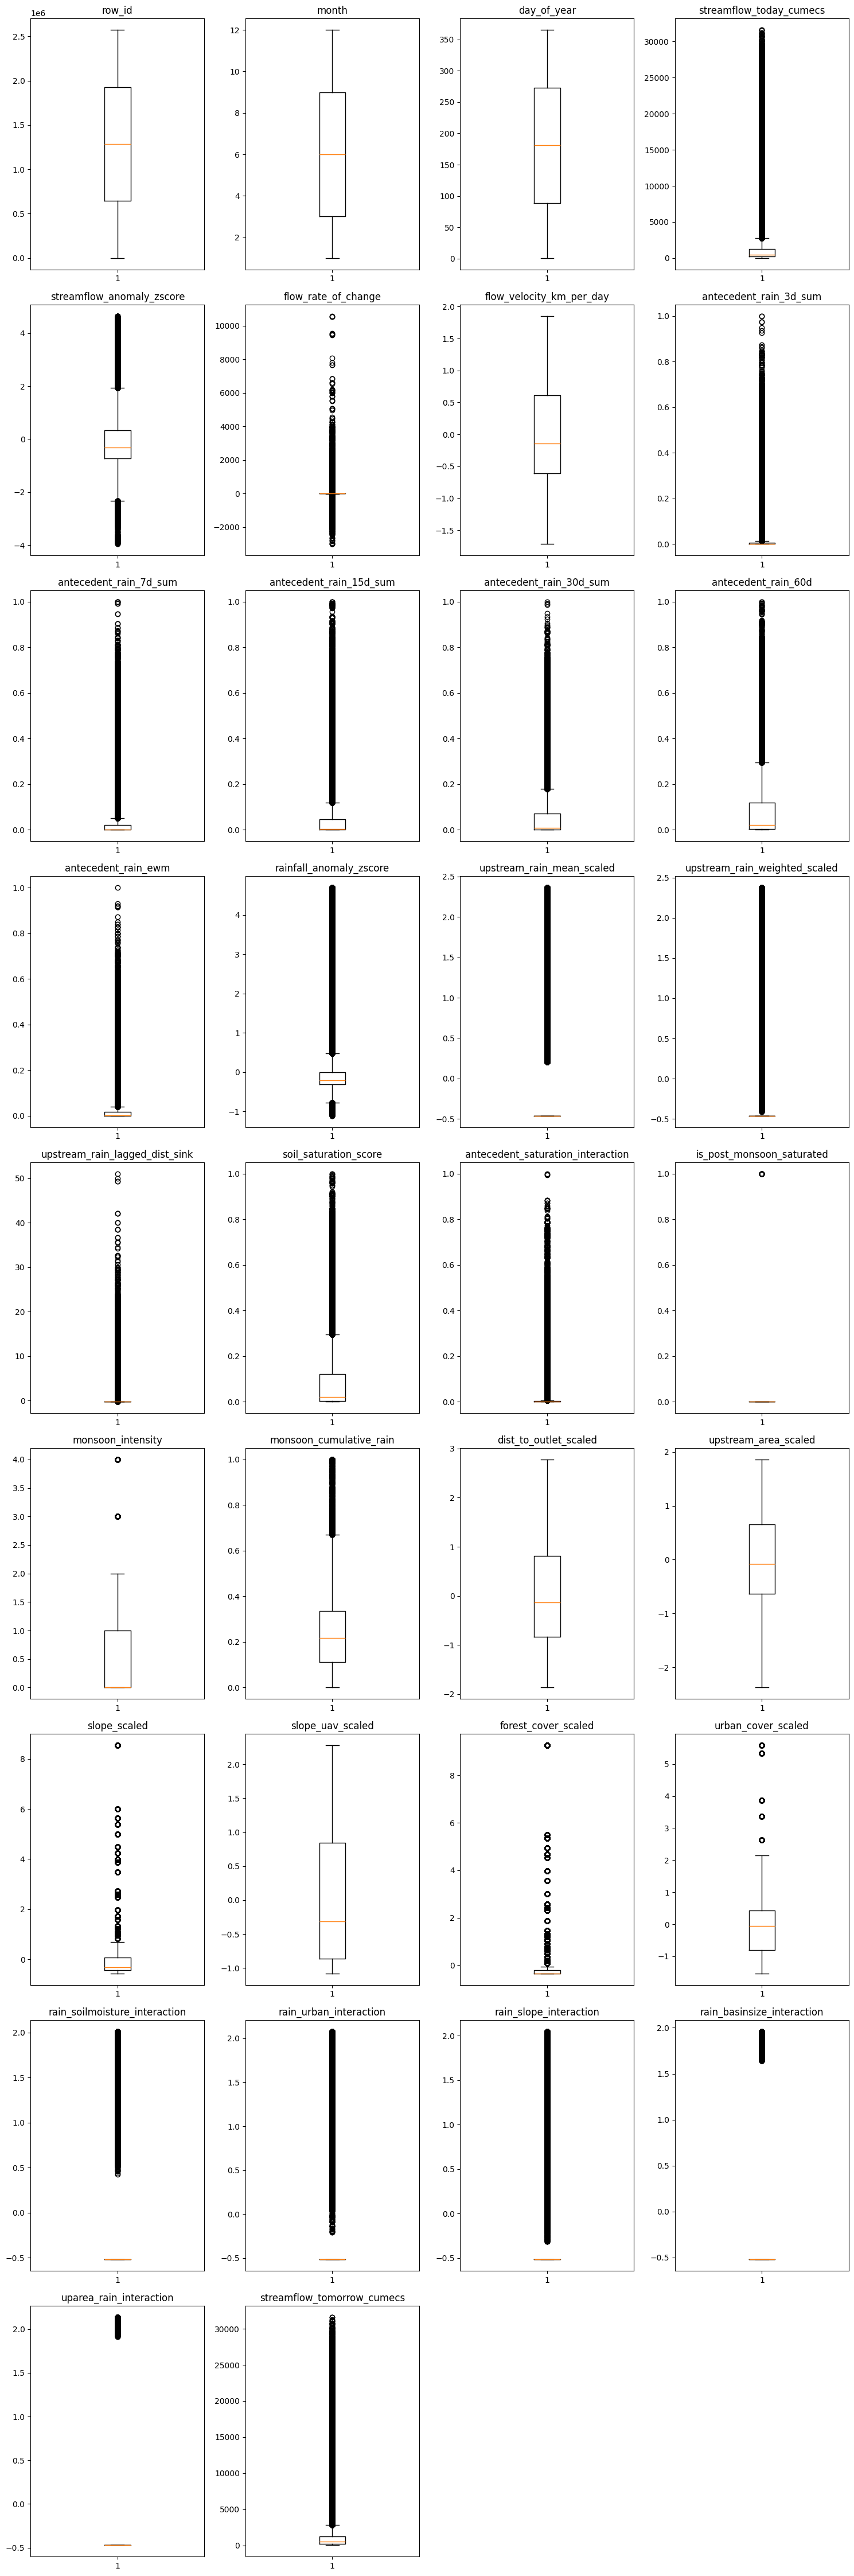

In [12]:
#Creating function to visualise all columns using boxplot that help us to detect outlier

def visualise(train_data):
    n_cols=4
    num_cols = train_data.select_dtypes(include=['int64', 'float64']).columns
    n_rows = math.ceil(len(num_cols) / n_cols)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    
    axes = axes.flatten()
    for i, col in enumerate(num_cols):
        axes[i].boxplot(train_data[col].dropna())
        axes[i].set_title(col)
        
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

visualise(train_data)


In [13]:
def outlier(dataset):
    columns=list(dataset.columns)
    for column in columns[1:len(columns)]:
        Q1 = dataset[column].quantile(0.05)
        Q3 = dataset[column].quantile(0.95)
        IQR = Q3 - Q1
        lower_limit = Q1 - 1.5 * IQR
        upper_limit= Q3 + 1.5 * IQR
        dataset[column] = dataset[column].clip(
            lower=lower_limit,upper=upper_limit)
    print("outlier prevention succesfully")
    return dataset

train=outlier(train_data)




outlier prevention succesfully


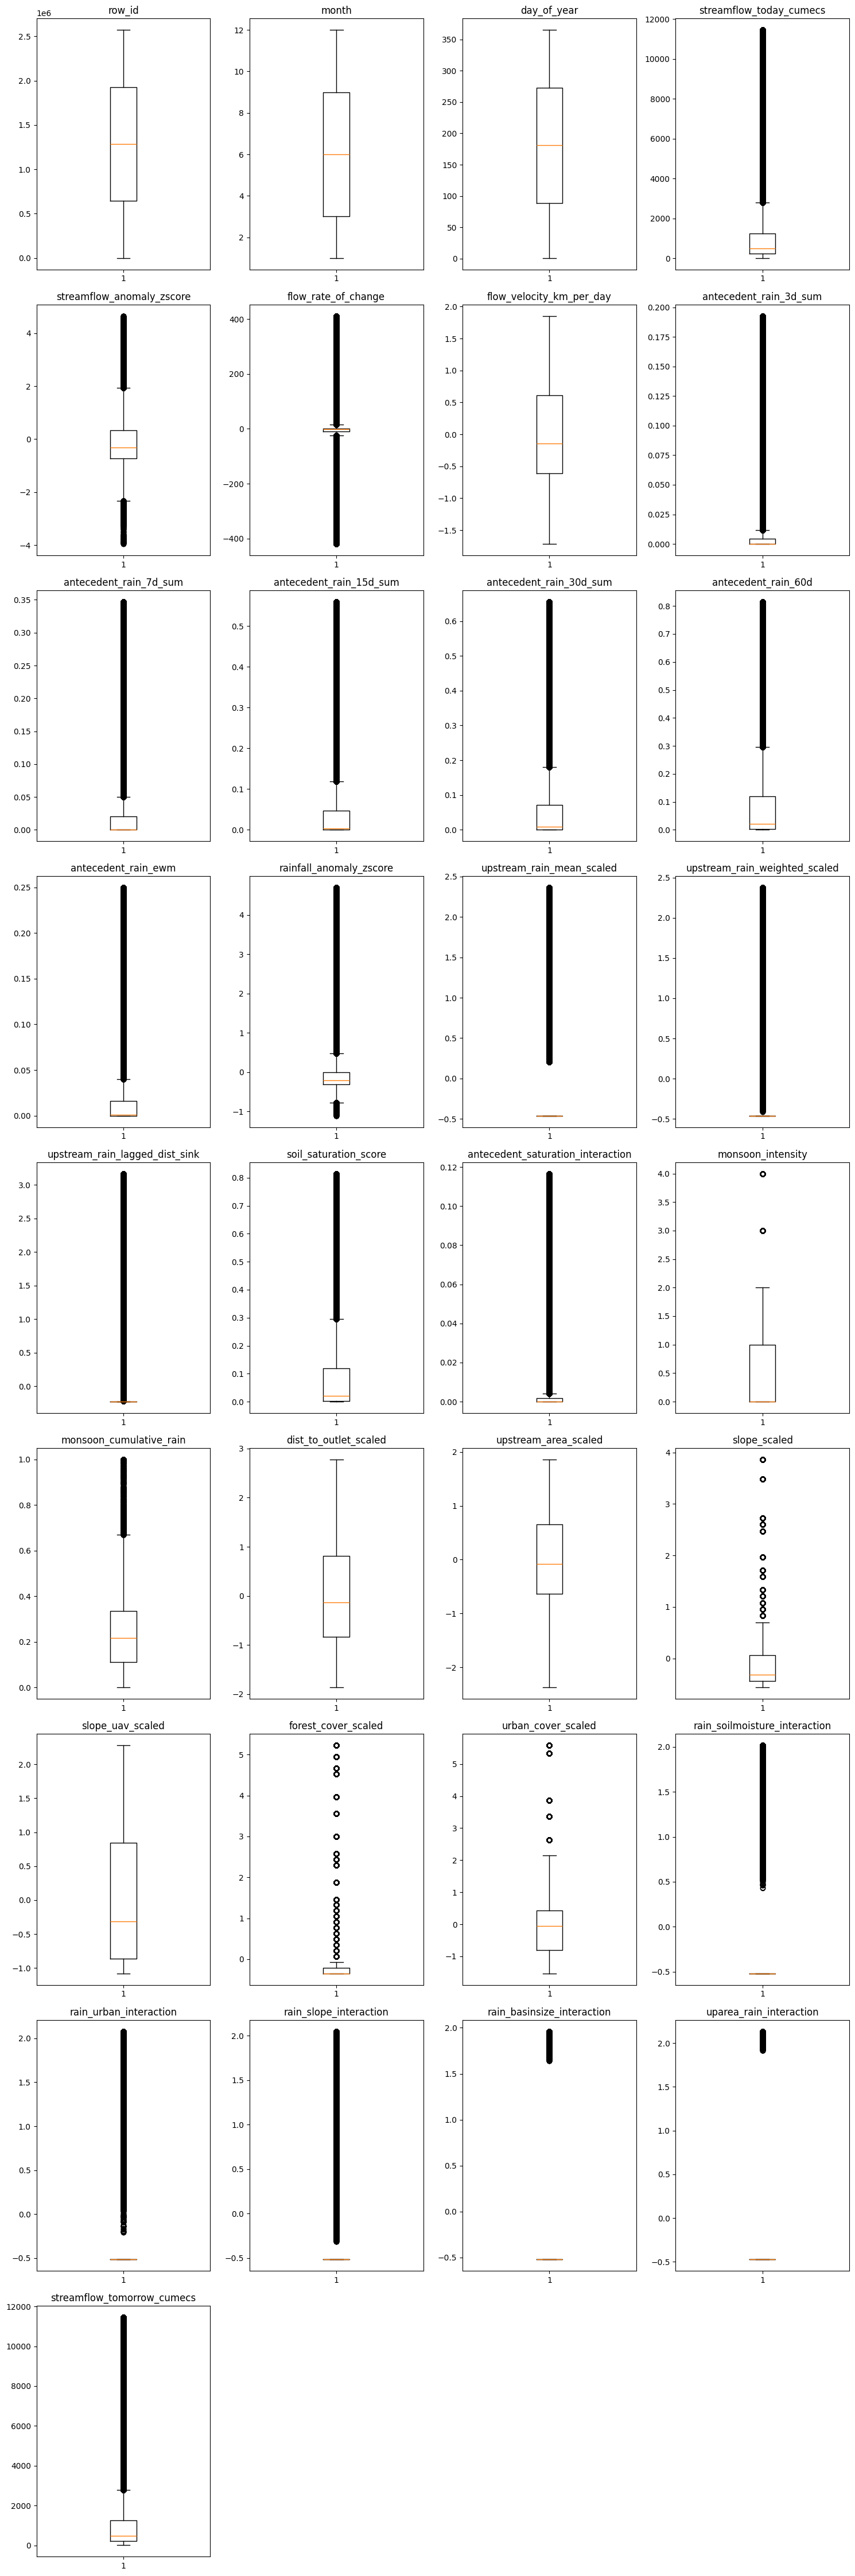

In [14]:
#Visualise all columns after after outlier prevention
visualise(train)

In [15]:
def feature(train):
    train["flow_lag_1"] = (train["streamflow_today_cumecs"].shift(1))
    train["flow_lag_3"] = (train["streamflow_today_cumecs"].shift(3))
    train["flow_lag_7"] = (train["streamflow_today_cumecs"].shift(7))
    train["lag_14"] = (train["streamflow_today_cumecs"].shift(14))
    train["lag_30"] = (train["streamflow_today_cumecs"].shift(30))
    train["rolling_mean_7"] = (train["streamflow_today_cumecs"].rolling(7).mean())
    train["rolling_std_7"] = (train["streamflow_today_cumecs"].rolling(7).std())
    train["diff_1"] = (train["streamflow_today_cumecs"] -train["flow_lag_1"])
    train["ratio_7"] = (train["streamflow_today_cumecs"] /(train["rolling_mean_7"] + 1e-5))
    train["ema_7"] = (train["streamflow_today_cumecs"].ewm(span=7).mean())
    train["rolling_max_7"] = (train["streamflow_today_cumecs"].rolling(7).max())

    return train

train=feature(train)
train.fillna(train.median(),inplace=True)

In [16]:
train.corr()

,row_id,month,day_of_year,streamflow_today_cumecs,streamflow_anomaly_zscore,flow_rate_of_change,flow_velocity_km_per_day,antecedent_rain_3d_sum,antecedent_rain_7d_sum,antecedent_rain_15d_sum,...,flow_lag_3,flow_lag_7,lag_14,lag_30,rolling_mean_7,rolling_std_7,diff_1,ratio_7,ema_7,rolling_max_7
row_id,1.000000e+00,8.862178e-03,2.737029e-02,0.019639,0.089229,-0.003114,0.000006,-0.009747,-0.012739,-0.014621,...,0.019640,0.019642,0.019645,0.019653,0.032699,0.032515,-2.578704e-07,0.000166,0.032699,0.032970
month,8.862178e-03,1.000000e+00,5.533335e-01,0.264312,0.033484,-0.060973,-0.000003,0.196894,0.244245,0.305547,...,0.264331,0.264355,0.264399,0.264488,0.440104,0.446063,-7.611699e-06,-0.000079,0.440094,0.456952
day_of_year,2.737029e-02,5.533335e-01,1.000000e+00,0.187891,0.007990,-0.067830,-0.000004,0.093372,0.121372,0.162868,...,0.187919,0.187953,0.188009,0.188143,0.312879,0.321389,-9.003713e-06,-0.000236,0.312872,0.331553
streamflow_today_cumecs,1.963896e-02,2.643117e-01,1.878908e-01,1.000000,0.209832,-0.093327,-0.016115,0.264855,0.326285,0.386976,...,0.253443,0.254863,0.252346,0.255861,0.600669,0.561069,6.105622e-01,0.601860,0.733663,0.556878
streamflow_anomaly_zscore,8.922935e-02,3.348423e-02,7.990081e-03,0.209832,1.000000,0.048182,0.000013,0.259081,0.290226,0.288708,...,0.144130,0.144147,0.143998,0.143897,0.255507,0.230264,5.371252e-02,0.052105,0.267206,0.235420
flow_rate_of_change,-3.113969e-03,-6.097257e-02,-6.783015e-02,-0.093327,0.048182,1.000000,0.003189,0.122713,0.057350,0.002987,...,-0.022120,-0.022041,-0.021999,-0.021772,-0.054121,-0.065862,-5.817083e-02,-0.056668,-0.066749,-0.067262
flow_velocity_km_per_day,6.371479e-06,-2.617118e-06,-3.927407e-06,-0.016115,0.000013,0.003189,1.000000,-0.009847,-0.013783,-0.016261,...,-0.000572,0.000517,-0.000558,-0.000071,-0.004169,0.000707,-1.272086e-02,0.004101,-0.006970,-0.000245
antecedent_rain_3d_sum,-9.747131e-03,1.968940e-01,9.337212e-02,0.264855,0.259081,0.122713,-0.009847,1.000000,0.786395,0.639989,...,0.233903,0.235110,0.234365,0.232101,0.397066,0.380827,2.436844e-02,0.023059,0.402782,0.387276
antecedent_rain_7d_sum,-1.273850e-02,2.442447e-01,1.213723e-01,0.326285,0.290226,0.057350,-0.013783,0.786395,1.000000,0.828294,...,0.290880,0.293058,0.291552,0.291336,0.494014,0.477828,2.753062e-02,0.026552,0.500431,0.485439
antecedent_rain_15d_sum,-1.462120e-02,3.055467e-01,1.628680e-01,0.386976,0.288708,0.002987,-0.016261,0.639989,0.828294,1.000000,...,0.350262,0.352040,0.350723,0.351197,0.592889,0.582865,2.953880e-02,0.028160,0.599504,0.591405


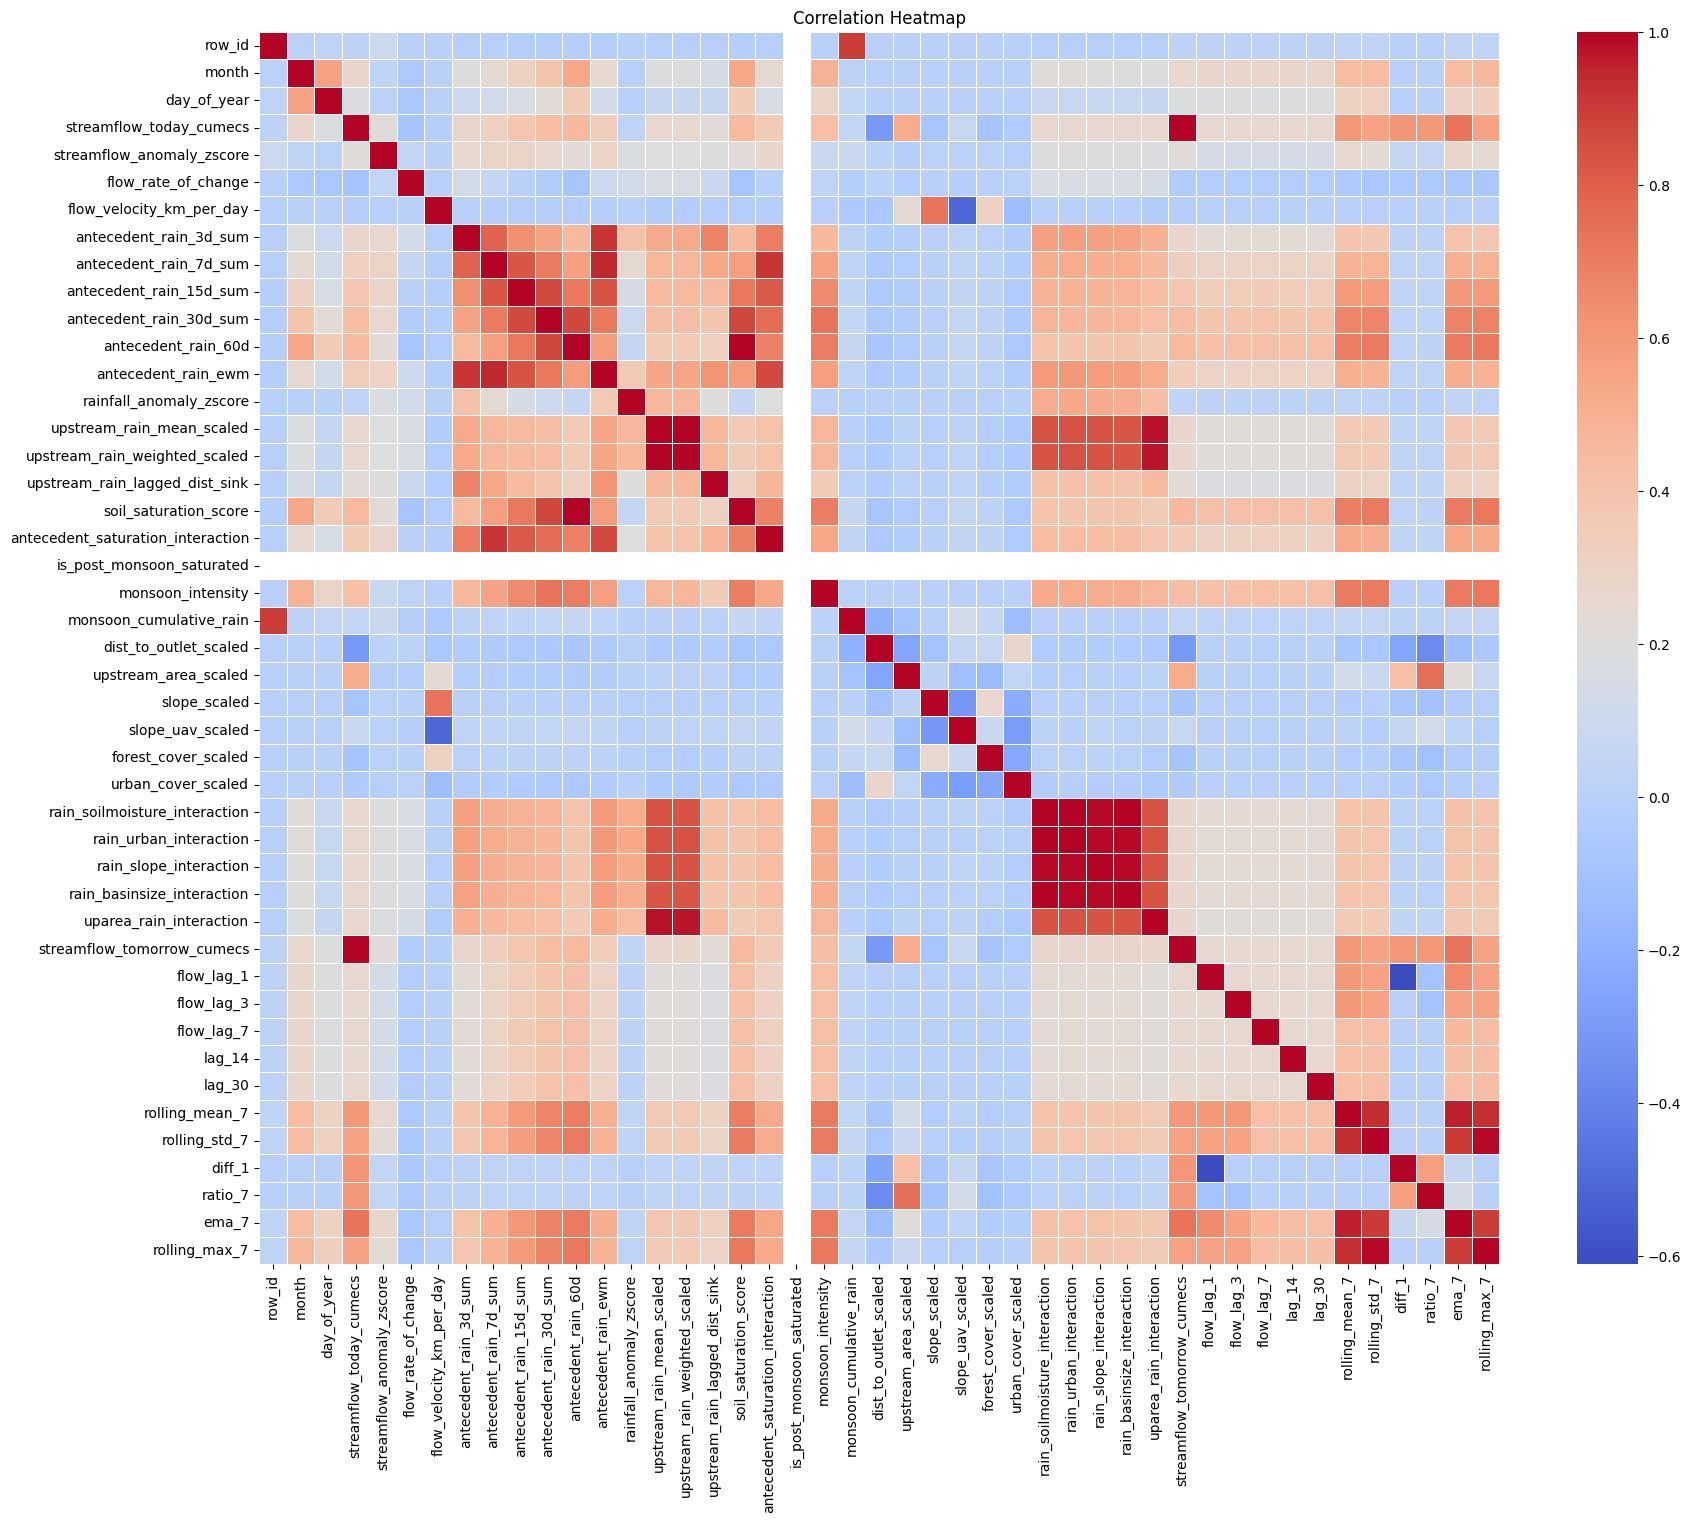

In [17]:
def heat_map(train):
    plt.figure(figsize=(20, 16))
    corr = train.corr(numeric_only=True)
    sns.heatmap(
        corr,
        annot=False,
        cmap="coolwarm",
        linewidths=0.5
    )

    plt.title("Correlation Heatmap")
    plt.show()

heat_map(train)

In [18]:
# Remove NaN rows
remove_cols = [
    "row_id",
    "month",
    "antecedent_rain_30d_sum",
    "antecedent_rain_60d",
    "rolling_max_7",
    "rain_basinsize_interaction",
    "uparea_rain_interaction",
    "ratio_7",
    "streamflow_tomorrow_cumecs"
    
]

# Features and target
X = train.drop(remove_cols,axis=1)

y = train["streamflow_tomorrow_cumecs"]

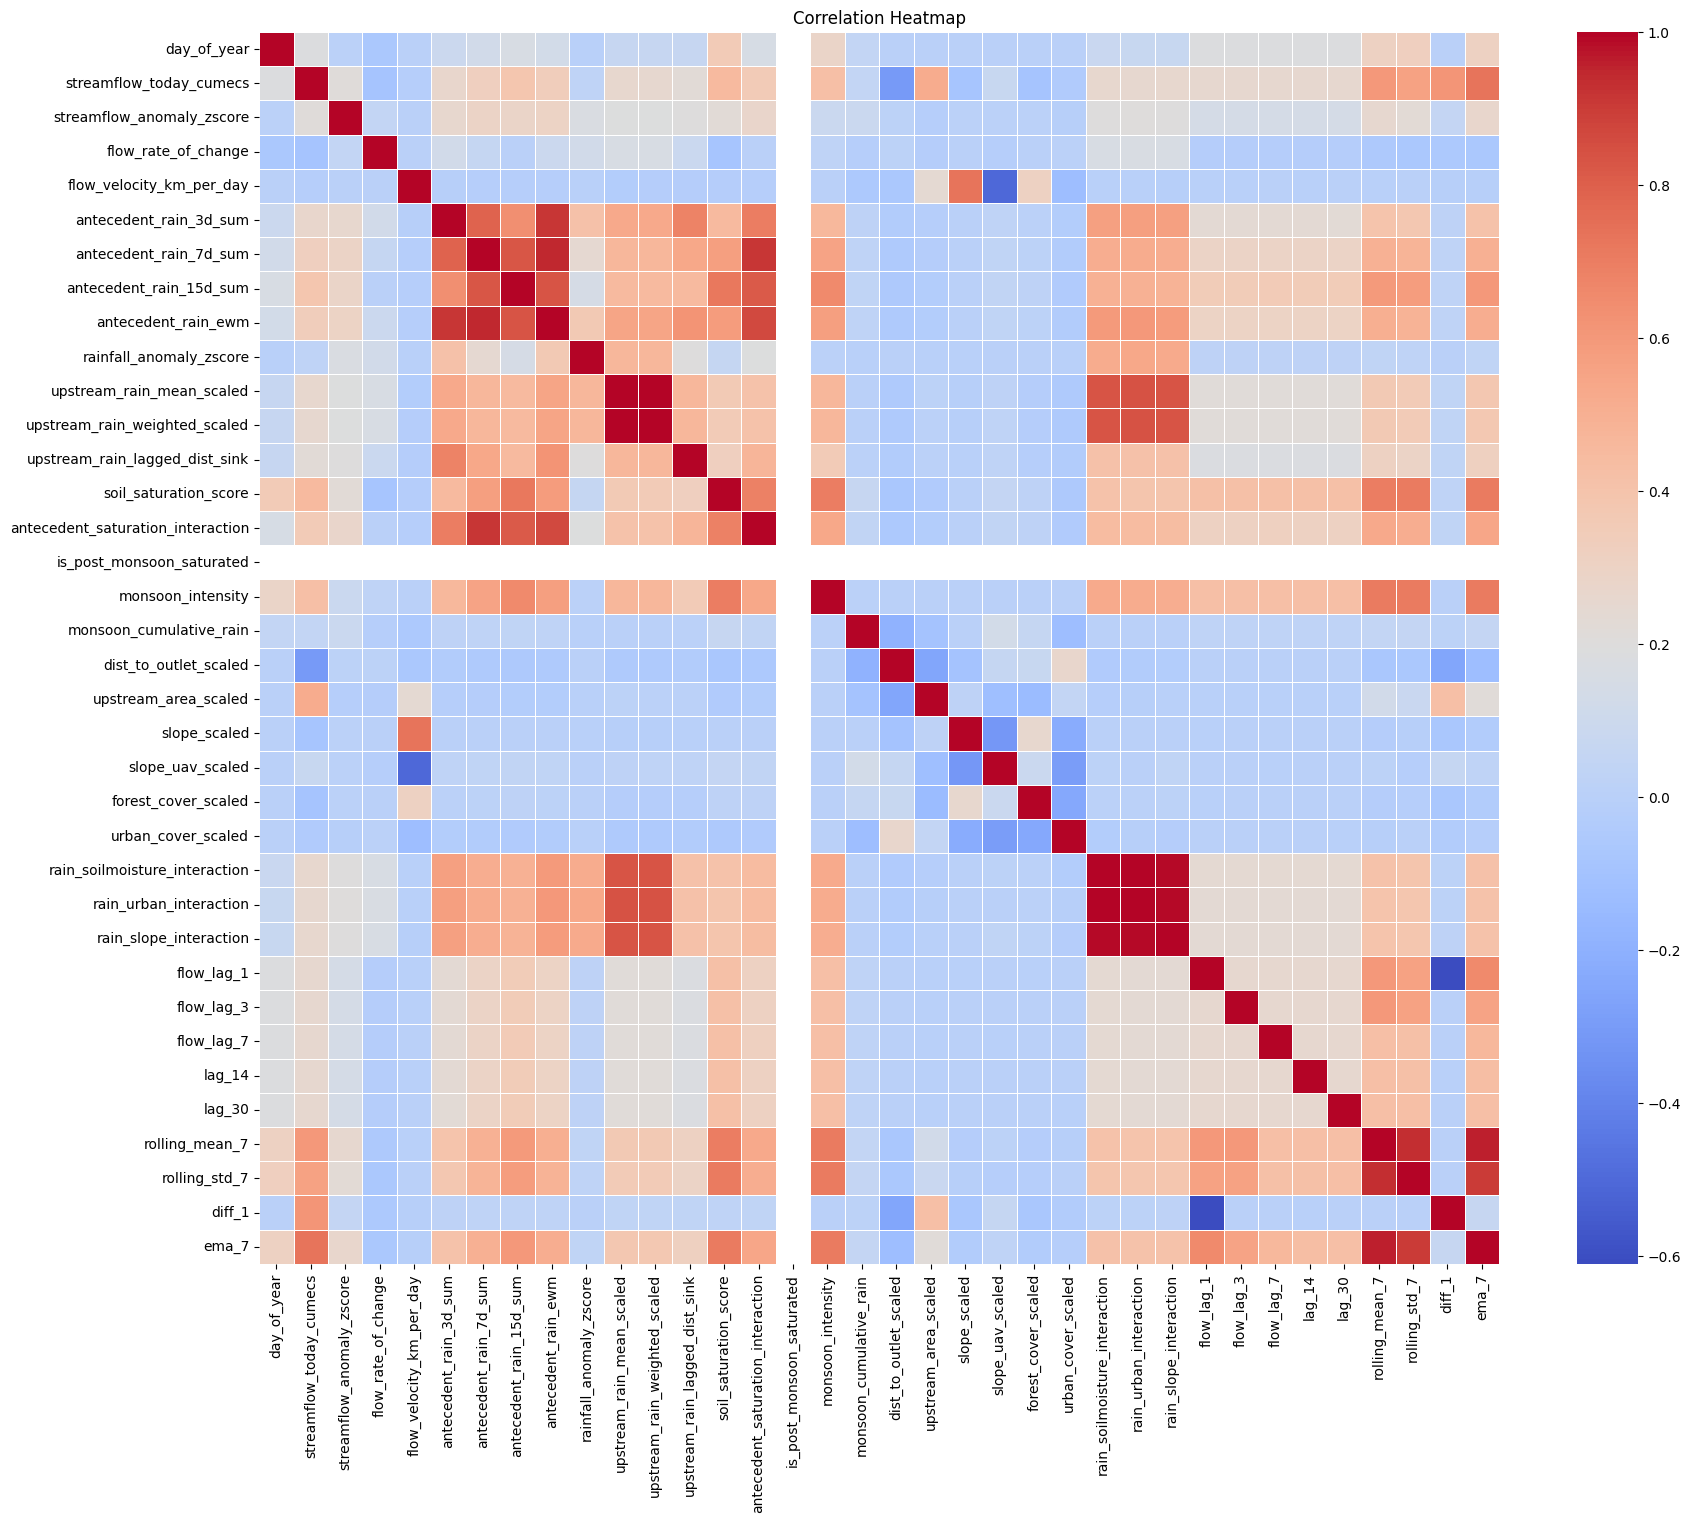

In [19]:
heat_map(X)

In [21]:
model = Sequential([
    Dense(64,kernel_initializer="he_uniform", activation='relu', input_shape=(X.shape[1],)),
    BatchNormalization(),
    Dropout(0.15),

    Dense(32,kernel_initializer="he_uniform", activation='relu'),
    BatchNormalization(),
    Dropout(0.15),

    Dense(16,kernel_initializer="he_uniform", activation='relu'),

    Dense(1)   # Regression output
    ])

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['r2_score']
)

scaler = StandardScaler()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-05-19 03:11:24.796956: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [ ]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
import numpy as np

tscv = TimeSeriesSplit(n_splits=5)

scores = []

for train_index, val_index in tscv.split(X):

    # Split data
    X_train = X.iloc[train_index]
    X_val = X.iloc[val_index]

    y_train = y.iloc[train_index]
    y_val = y.iloc[val_index]

    # Standard Scaling

    X_train_scaled = scaler.fit_transform(X_train)

    # IMPORTANT:
    # use only transform on validation data
    X_val_scaled = scaler.transform(X_val)

    model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=10,
    batch_size=128   # TPU works better with larger batch sizes
)

    # Prediction
    pred = model.predict(X_val_scaled)

    # Evaluation
    score = r2_score(y_val, pred)

    scores.append(score)

    print("Fold Score:", score)

print("Average Score:", np.mean(scores))




Epoch 1/10
3348/3348 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - loss: 1680082.2500 - r2_score: 0.3395 - val_loss: 18128.5098 - val_r2_score: 0.9941
Epoch 2/10
3348/3348 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - loss: 110176.4531 - r2_score: 0.9571 - val_loss: 19948.2441 - val_r2_score: 0.9935
Epoch 3/10
3348/3348 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - loss: 83964.1641 - r2_score: 0.9671 - val_loss: 10025.8535 - val_r2_score: 0.9967
Epoch 4/10
3348/3348 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - loss: 72395.4375 - r2_score: 0.9714 - val_loss: 11155.5488 - val_r2_score: 0.9963
Epoch 5/10
3348/3348 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - loss: 63040.2227 - r2_score: 0.9750 - val_loss: 8830.0586 - val_r2_score: 0.9971
Epoch 6/10
3348/3348 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - loss: 56581.2031 - r2_score: 0.9777 - val_loss: 10252.7188 - val_r2_score: 0.9966
Epoch 7/10
3348/3348 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - loss: 51178.5859 - r2_score: 0.9801 - val_loss: 7723.3989 - val_r2_score: 0.9975
Epoch 8/10
3348/3348 ━━━━━

In [34]:
model.save("model1.keras")

In [24]:
test="/kaggle/input/datasets/ankushpal45/competition/aether-iiit-lucknow-stream-flow-prediction-challenge-2026/test_flood.csv"
df=pd.read_csv(test)
df.head()
df.shape

(642764, 33)

In [25]:
df=feature(df)

In [26]:
df.fillna(df.median(), inplace=True)

In [27]:
df.shape

(642764, 44)

In [28]:
remove= [
    "row_id",
    "month",
    "antecedent_rain_30d_sum",
    "antecedent_rain_60d",
    "rolling_max_7",
    "rain_basinsize_interaction",
    "uparea_rain_interaction",
    "ratio_7",
]

In [29]:
X=df.drop(remove,axis=1)

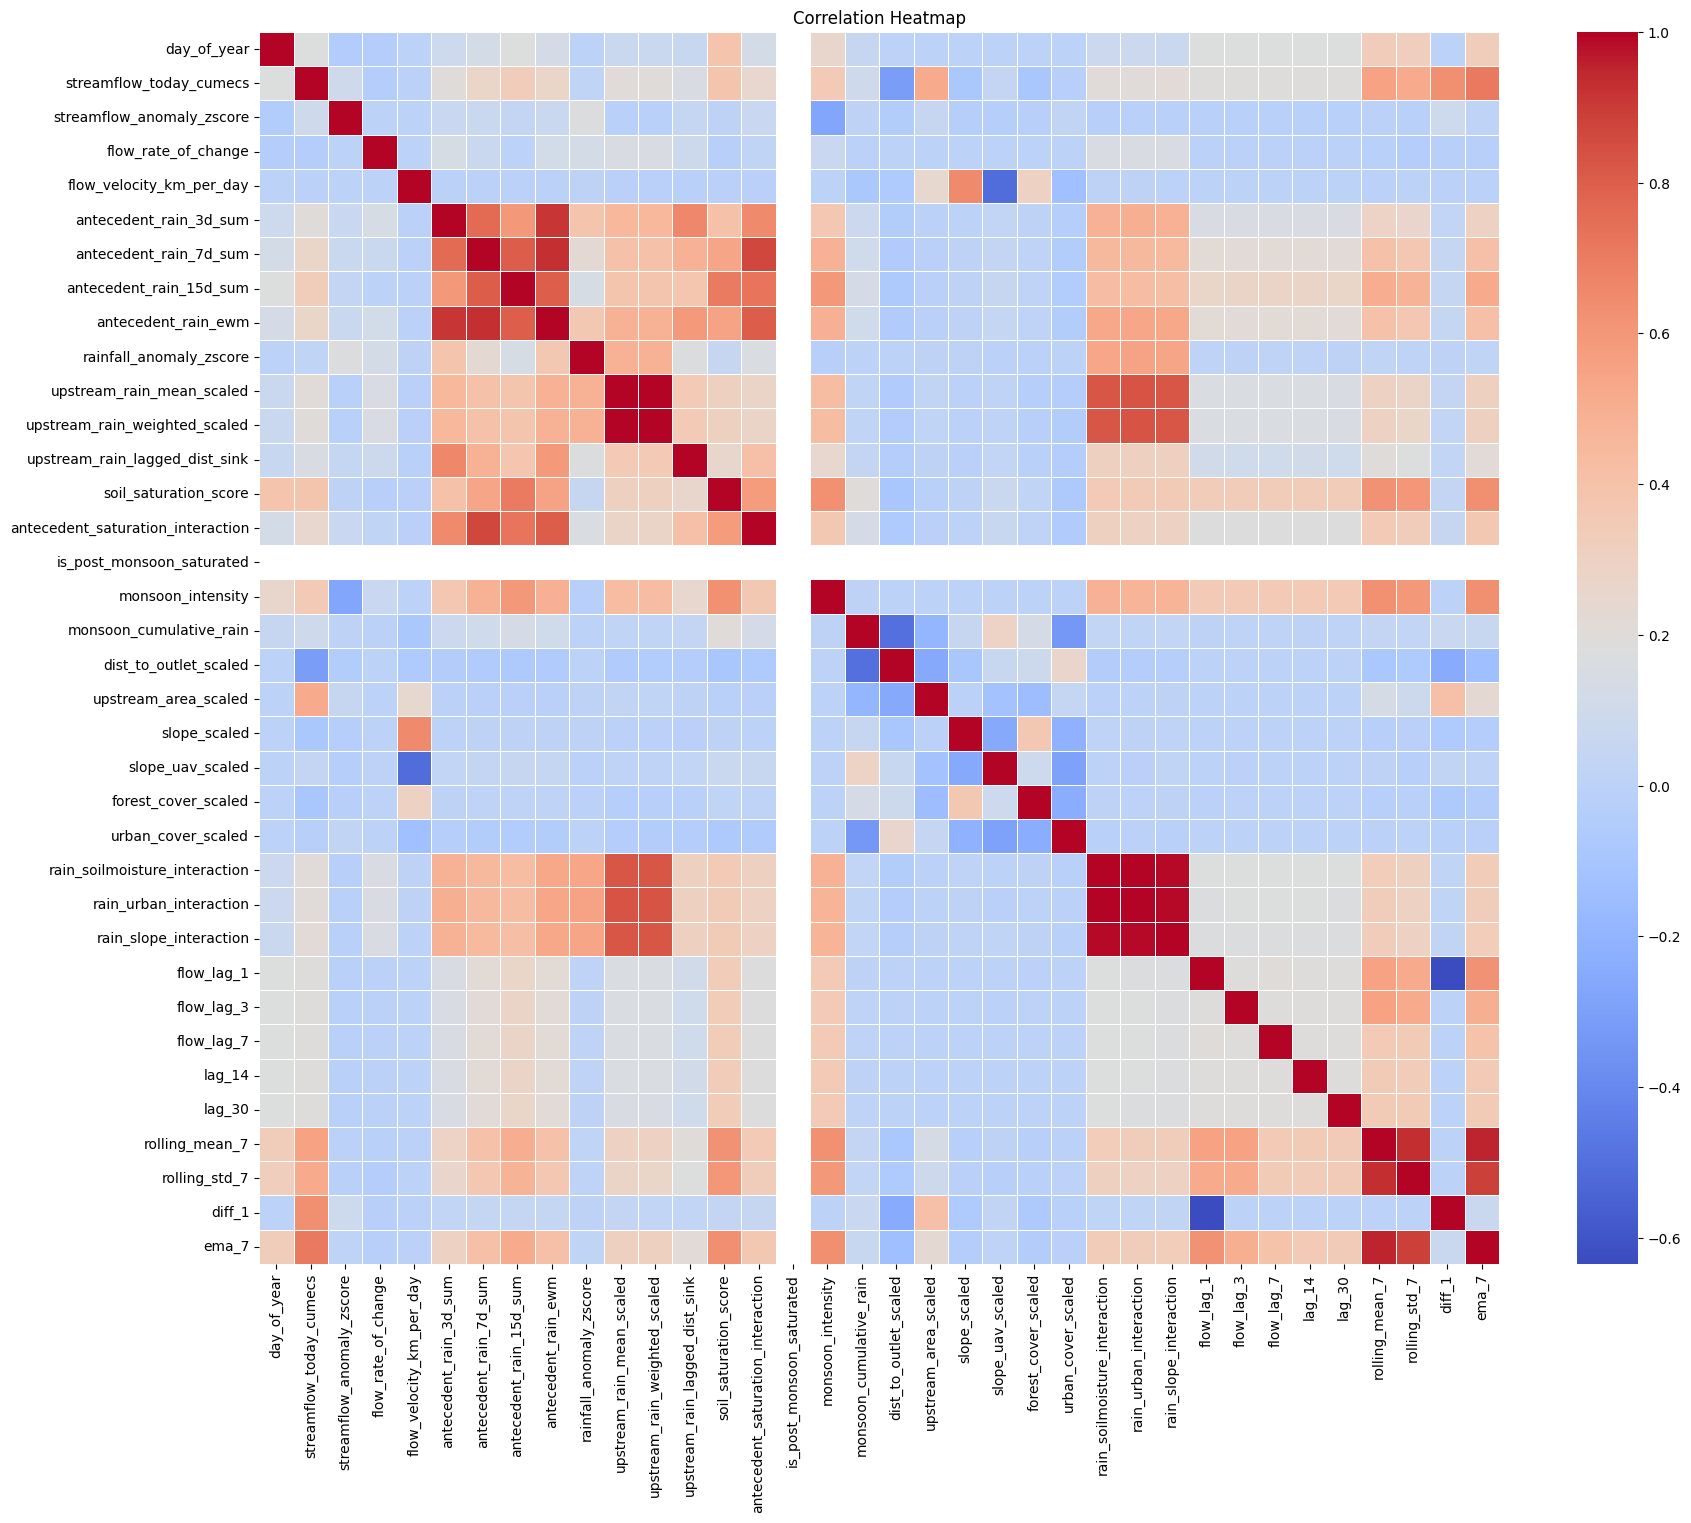

In [30]:
heat_map(X)

In [31]:
X.head()
X.shape

(642764, 36)

In [32]:
x_tranform=scaler.transform(X)


In [35]:
from tensorflow.keras.models import load_model
model=load_model("/kaggle/working/model1.keras")

In [36]:
pred=model.predict(x_tranform)

20087/20087 ━━━━━━━━━━━━━━━━━━━━ 27s 1ms/step


In [39]:
print(pred)

[[362.9015 ]
 [623.19684]
 [253.76727]
 ...
 [547.92554]
 [261.16968]
 [117.97394]]


In [40]:
data=[]
for i in pred:
    data.append(i[0])



In [41]:
right=pd.DataFrame({"row_id":df["row_id"],"streamflow_tomorrow_cumecs":data})

In [42]:
negative_rows = right[right["streamflow_tomorrow_cumecs"] < 0]
print(len(negative_rows))

0


In [ ]:
combined.head(60)

In [43]:
right.to_csv(

    "sample_submission8.csv",

    index=False
)